In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setting up the path and importing the dataframe
tox_khan = pd.read_csv("../data/01_raw/tox_khan.csv")

print(f"Number of rows (molecules) in the Tox Khan Dataset: {len(tox_khan)}")

Number of rows (molecules) in the Tox Khan Dataset: 2588


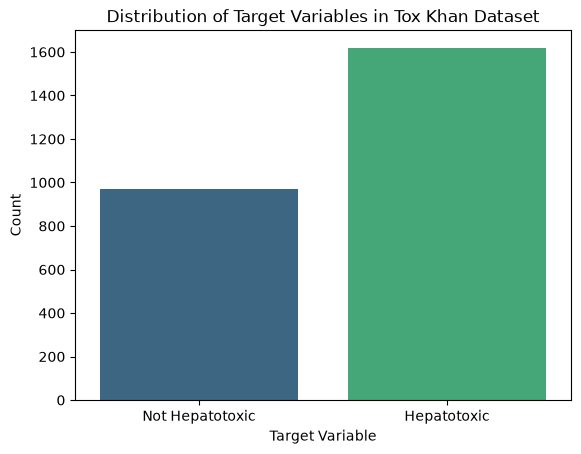

In [10]:
# Visualizing the distribution of target variables using seaborn
sns.countplot(x='Target', data=tox_khan, hue='Target',legend=False, palette='viridis')
plt.title('Distribution of Target Variables in Tox Khan Dataset')
plt.xticks(ticks=[0, 1], labels=['Not Hepatotoxic', 'Hepatotoxic'])
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()

In [11]:
tox21 = pd.read_csv("../data/01_raw/tox21.csv")

print(tox21.head())
print(f"Number of rows (molecules) in dataset: {tox21.shape[0]}")

# Extracting the 3 pathways relating to hepatotoxicity and removing rows with missing values for all 3 pathways
tox21_clean = tox21[['smiles', 'SR-ARE', 'SR-MMP', 'NR-PPAR-gamma']]
tox21_clean = tox21_clean.dropna(subset=['SR-ARE', 'SR-MMP', 'NR-PPAR-gamma'], how='all')

print(tox21_clean.head())
print(f"Number of rows (molecules) in dataset after removing missing values for all 3 pathways: {tox21_clean.shape[0]}")

   NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0    0.0        0.0     1.0           NaN    NaN        0.0            0.0   
1    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
2    NaN        NaN     NaN           NaN    NaN        NaN            NaN   
3    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
4    0.0        0.0     0.0           0.0    0.0        0.0            0.0   

   SR-ARE  SR-ATAD5  SR-HSE  SR-MMP  SR-p53    mol_id  \
0     1.0       0.0     0.0     0.0     0.0   TOX3021   
1     NaN       0.0     NaN     0.0     0.0   TOX3020   
2     0.0       NaN     0.0     NaN     NaN   TOX3024   
3     NaN       0.0     NaN     0.0     0.0   TOX3027   
4     0.0       0.0     0.0     0.0     0.0  TOX20800   

                                              smiles  
0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1  
1                          CCN1C(=O)NC(c2ccccc2)C1=O  
2  CC[C@]1(O)CC[C@H]2[C

In [12]:
# Removing rows with missing values for any pathway and creating a target variable using pathway values
tox21_final = tox21_clean.dropna(subset=['SR-ARE', 'SR-MMP', 'NR-PPAR-gamma'], how='any', ignore_index=True)
tox21_final['Target'] = ((tox21_final[['SR-ARE', 'SR-MMP', 'NR-PPAR-gamma']] > 0).any(axis=1)).astype(int)

#Calculating the percentage of molecules lost due to missing values
print(tox21_final.head())

print(f"------------------ METRICS ------------------")
print(f"Number of rows (molecules) in dataset after removing missing values for any pathway: {tox21_final.shape[0]}")
print(f'Number of rows (molecules) lost due to missing values: {tox21_clean.shape[0] - tox21_final.shape[0]}')
print(f"Percentage of molecules lost due to missing values: {(tox21_clean.shape[0] - tox21_final.shape[0]) / tox21_clean.shape[0] * 100:.2f}%")

                                            smiles  SR-ARE  SR-MMP  \
0                     CCOc1ccc2nc(S(N)(=O)=O)sc2c1     1.0     0.0   
1                        CC(O)(P(=O)(O)O)P(=O)(O)O     0.0     0.0   
2                              O=S(=O)(Cl)c1ccccc1     0.0     0.0   
3  O=c1[nH]c(=O)n([C@H]2C[C@H](O)[C@@H](CO)O2)cc1I     0.0     0.0   
4                                CC(C)COC(=O)C(C)C     0.0     0.0   

   NR-PPAR-gamma  Target  
0            0.0       1  
1            0.0       0  
2            0.0       0  
3            0.0       0  
4            0.0       0  
------------------ METRICS ------------------
Number of rows (molecules) in dataset after removing missing values for any pathway: 4189
Number of rows (molecules) lost due to missing values: 3337
Percentage of molecules lost due to missing values: 44.34%


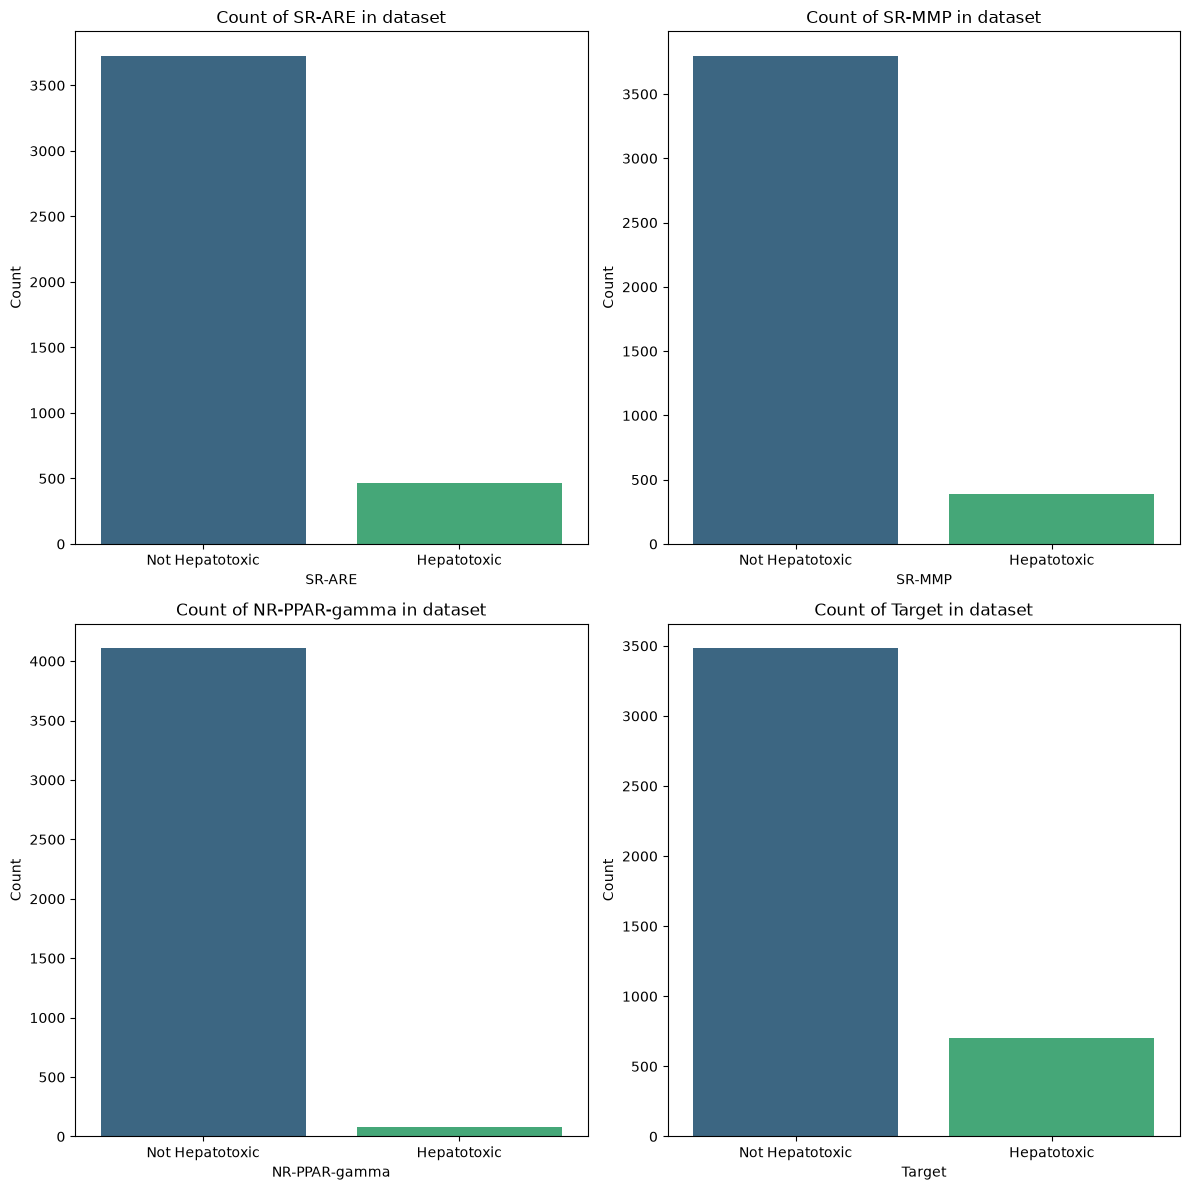

In [8]:
# Visualizing the distribution of molecules across different pathways plus the created target variable
cols = ['SR-ARE', 'SR-MMP', 'NR-PPAR-gamma', 'Target']

fig, axs = plt.subplots(2, 2, figsize=(12, 12))

for column in cols:
    sns.countplot(x=column, data=tox21_final, hue=column,  palette='viridis', legend=False, ax=axs[cols.index(column) // 2][cols.index(column) % 2])
    axs[cols.index(column) // 2][cols.index(column) % 2].set_title(f'Count of {column} in dataset')
    axs[cols.index(column) // 2][cols.index(column) % 2].set_xlabel(column)
    axs[cols.index(column) // 2][cols.index(column) % 2].set_xticks([0, 1], ['Not Hepatotoxic', 'Hepatotoxic'])
    axs[cols.index(column) // 2][cols.index(column) % 2].set_ylabel('Count')
plt.tight_layout()

# Saving the fully cleaned tox21 dataset to a CSV file
tox21_final.to_csv("../data/03_processed/tox21_final.csv", index=False)